# Classification de dialogues
Damien PERES, Mathis Cotonnec, Solo Peyret




## I - Chargement et lecture des données DailyDialog

In [2]:
import pandas as pd

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

print(train_df.head())

                                              dialog                    act  \
0  ['Say , Jim , how about going for a few beers ...  [3 4 2 2 2 3 4 1 3 4]   
1  ['Can you do push-ups ? '\n " Of course I can ...          [2 1 2 2 1 1]   
2  ['Can you study with the radio on ? '\n ' No ,...            [2 1 2 1 1]   
3  ['Are you all right ? '\n ' I will be all righ...              [2 1 1 1]   
4  ['Hey John , nice skates . Are they new ? '\n ...    [2 1 2 1 1 2 1 3 4]   

                 emotion  
0  [0 0 0 0 0 0 4 4 4 4]  
1          [0 0 6 0 0 0]  
2            [0 0 0 0 0]  
3              [0 0 0 0]  
4    [0 0 0 0 0 6 0 6 0]  


Le code ci-dessous permet d'extraire :
* les dialogues complets (incluant plusieurs échanges entre des personnes)
* les séquences de labels associés aux dialogues
* les phrases isolées, extraites de l'ensemble des dialogues
* les labels associés à chacun des dialogues

Il est recommandé de traiter les phrases isolées avec leur label associé, au moins dans un premier temps !

In [3]:
import numpy as np

def split_custom(text):
    result = []
    buffer = []
    in_double_quotes = False
    i = 0

    while i < len(text):
        char = text[i]

        # Gestion des guillemets doubles
        if char == '"':
            if buffer:
                result.append("".join(buffer).strip())
                buffer = []
            in_double_quotes = not in_double_quotes
            i += 1
            continue

        # Gestion des guillemets simples (hors guillemets doubles)
        if not in_double_quotes and char == "'":
            prev_char = text[i - 1] if i > 0 else ""
            next_char = text[i + 1] if i + 1 < len(text) else ""

            if prev_char == " " or next_char == " ":
                if buffer:
                    result.append("".join(buffer).strip())
                    buffer = []
                i += 1
                continue

        buffer.append(char)
        i += 1

    if buffer:
        result.append("".join(buffer).strip())

    return result


def extract_utterances(df):
    dialogues_complets = []
    labels_dialogues_complets = []
    phrases_dialogues = []
    labels_phrases = []

    for _, row in df.iterrows():
        dialog = row["dialog"]
        intent_seq = row["act"].replace("[", "").replace("]", "")

        # Découpage des tours
        d_list = [u.strip().lower() for u in dialog.split("__eou__") if u.strip()]
        a_list = list(map(int, intent_seq.split()))
        a_list = [a-1 for a in a_list]

        # conservation des dialogues complets
        for d in d_list:
            dialogues_complets.append(d)
        labels_dialogues_complets.append(a_list)

        # découpage des dialogues en phrases isolées
        for i,d in enumerate(d_list):
          phrases = []
          phrases_seq = " ".join(d.replace("[", "").replace("]", "").split('\n'))
          if 1:
            phrases_tmp = split_custom(phrases_seq)
            phrases = [p for p in phrases_tmp if len(p.strip())>0]

          if len(phrases) == len(a_list):
            for j,phrase in enumerate(phrases):
              phrases_dialogues.append(phrase)
              labels_phrases.append(a_list[j])

    return dialogues_complets, labels_dialogues_complets, phrases_dialogues, np.array(labels_phrases)

X_dial_train, y_dial_train, X_phrases_train, y_phrases_train = extract_utterances(train_df)
X_dial_val, y_dial_val, X_phrases_val, y_phrases_val = extract_utterances(val_df)
X_dial_test, y_dial_test, X_phrases_test, y_phrases_test = extract_utterances(test_df)


## II - Vectorisation

Phrase la plus longue : 278 mots
Longueur moyenne : 13.58 mots

Contenu de la phrase la plus longue :
'i have had an incredible boss , who was my direct supervisor during the last year of my coop work experience . a-bout two months after i began working for her , she really let me spread my wings . she encouraged me to work independently , because she said she had come to trust my judgment and commitment . so i was able to move forward on projects without having to check in with her every day . of course , i made certain that she knew what i had accomplished on a daily and weekly basis because i gave her summary reports , although she didn't specifically ask me to . without her support and encouragement , i don't think i would have felt confident enough to have written up a proposal suggesting that the department change a process that had been in place for a long time . but she was open to suggestions , so long as employees could back them up with research and facts . when i submitted 

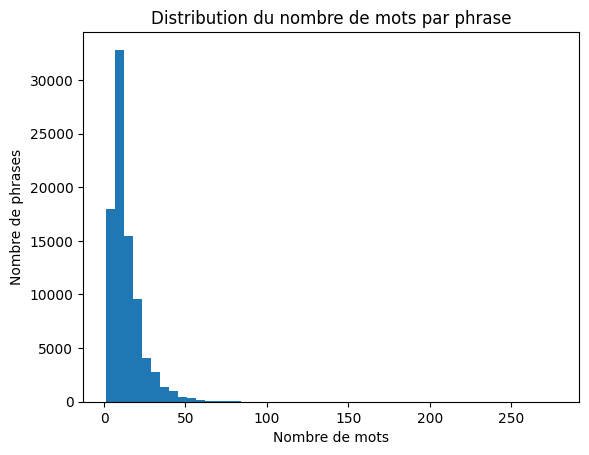

In [4]:
import matplotlib.pyplot as plt

lengths = [len(phrase.split()) for phrase in X_phrases_train]

max_length = max(lengths)
mean_length = sum(lengths) / len(lengths)

print(f"Phrase la plus longue : {max_length} mots")
print(f"Longueur moyenne : {mean_length:.2f} mots")

index_max = lengths.index(max_length)
print(f"\nContenu de la phrase la plus longue :\n'{X_phrases_train[index_max]}'")

plt.hist(lengths, bins=50)
plt.title("Distribution du nombre de mots par phrase")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de phrases")
plt.show()

L'analyse de la distribution des longueurs montre que la majorité des phrases contient moins de 50 mots. Nous fixons donc le paramètre MAX_LEN à 50 afin de couvrir la quasi-totalité du corpus sans alourdir inutilement les vecteurs d'entrée.

In [5]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#paramètres
MAX_WORDS = 10000       # 10k mots les plus fréquents
MAX_LEN = 50            # Longueur max d'une phrase, en complétant avec des 0
EMBEDDING_DIM = 100     # 100 caractéristiques abstraites pour décrire chaque mot

# tokenisation
# On apprend le vocabulaire uniquement sur le TRAIN pour ne pas biaiser
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_phrases_train)

# Conversion des textes en séquences d'entiers
X_train_seq = tokenizer.texts_to_sequences(X_phrases_train)
X_val_seq   = tokenizer.texts_to_sequences(X_phrases_val)
X_test_seq  = tokenizer.texts_to_sequences(X_phrases_test)

# padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# encodage des labels
num_classes = 4
y_train_enc = to_categorical(y_phrases_train, num_classes)
y_val_enc   = to_categorical(y_phrases_val, num_classes)
y_test_enc  = to_categorical(y_phrases_test, num_classes)

print("Données prêtes !")
print(f"Shape X_train: {X_train_pad.shape}")

Données prêtes !
Shape X_train: (86423, 50)


## III - Test de différents modèles

### 1. Modèle CNN

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Input + Embedding
inputs = Input(shape=(MAX_LEN,))
x = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)(inputs)

# On applique plusieurs filtres (kernel_size) pour capturer des motifs de tailles différentes
conv_3 = Conv1D(filters=128, kernel_size=3, activation='relu')(x)
pool_3 = GlobalMaxPooling1D()(conv_3)

conv_4 = Conv1D(filters=128, kernel_size=4, activation='relu')(x)
pool_4 = GlobalMaxPooling1D()(conv_4)

conv_5 = Conv1D(filters=128, kernel_size=5, activation='relu')(x)
pool_5 = GlobalMaxPooling1D()(conv_5)

# Concatenation + Regularisation
x = Concatenate()([pool_3, pool_4, pool_5])
x = Dropout(0.5)(x)

# Dense : classification
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

# Compilation
model = Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 100)   │  1,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 48, 128)   │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 47, 128)   │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 46, 128)   │     64,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     24,640 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,178,884 (4.50 MB)

 Trainable params: 1,178,884 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

ENTRAINEMENT

In [7]:
history = model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=8,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    ]
)

Epoch 1/8
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.6734 - loss: 0.8430 - val_accuracy: 0.7444 - val_loss: 0.6671
Epoch 2/8
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7819 - loss: 0.5794 - val_accuracy: 0.7347 - val_loss: 0.6731
Epoch 3/8
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8039 - loss: 0.5085 - val_accuracy: 0.7553 - val_loss: 0.6672


EVALUATION

241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

      Inform     0.7558    0.8979    0.8208      3506
    Question     0.9074    0.8400    0.8724      2194
   Directive     0.6595    0.6486    0.6540      1275
  Commissive     0.6379    0.2159    0.3226       718

    accuracy                         0.7764      7693
   macro avg     0.7402    0.6506    0.6674      7693
weighted avg     0.7721    0.7764    0.7614      7693



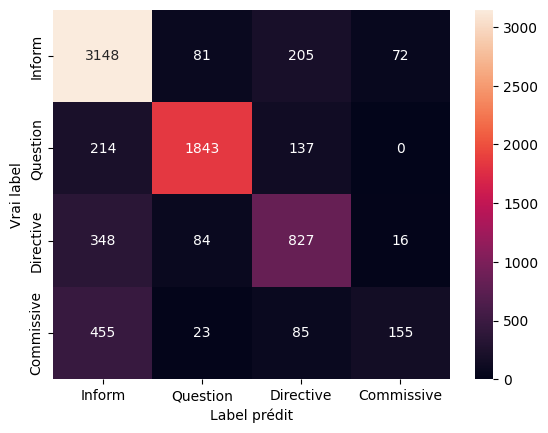

In [8]:
# Prédiction sur le jeu de test
y_pred_probs = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Noms des classes
target_names = ["Inform", "Question", "Directive", "Commissive"]

# Rapport complet
print(classification_report(y_phrases_test, y_pred_classes, target_names=target_names, digits=4))

# Matrice de confusion pour voir les erreurs fréquentes
cm = confusion_matrix(y_phrases_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Vrai label')
plt.xlabel('Label prédit')
plt.show()

**Conclusion sur le modèle CNN**

Le modèle TextCNN atteint une accuracy de 78,2% sur le jeu de test, ce qui constitue un résultat satisfaisant pour une approche de classification d’actes de dialogue phrase par phrase.

**Analyse des forces**

Le modèle présente d’excellentes performances sur la classe Question, avec un F1-score de 0.87. Cette efficacité s’explique par la capacité du CNN à détecter des caractéristiques, tels que la présence de mots interrogatifs (what, who, how) ou de structures syntaxiques propres aux phrases interrogatives.

La classe Inform est également bien traitée, avec un rappel élevé de 0.87, indiquant que le modèle identifie correctement la majorité des phrases informatives. Les filtres convolutionnels permettent de capter efficacement des expressions factuelles fréquentes, souvent suffisantes pour distinguer ce type d’acte de dialogue des autres catégories.

**Analyse des faiblesses**

Le modèle rencontre toutefois des difficultés importantes sur la classe Commissive. Malgré une précision correcte (0.63), le rappel reste très faible (0.25), ce qui signifie que près de 75% des phrases commissives ne sont pas détectées. Cette faiblesse s’explique principalement par le déséquilibre du jeu de données, la classe Commissive ne représentant que 9% des exemples, contre 45% pour la classe Inform. Le modèle tend ainsi à privilégier les classes majoritaires afin d’optimiser la performance globale.

La classe Directive obtient des performances intermédiaires, avec un F1-score de 0.67, suggérant une confusion partielle avec les classes Inform et Question. Cela indique que certains motifs lexicaux capturés par les convolutions sont partagés entre ces catégories, rendant la discrimination plus complexe en l’absence de contexte conversationnel.

**Résumé**

Le modèle TextCNN se révèle efficace et robuste pour la classification d’actes de dialogue à partir de phrases isolées. Sa capacité à exploiter des motifs locaux lui permet d’identifier correctement les classes majoritaires, en particulier Question et Inform. Néanmoins, le modèle reste fortement influencé par le déséquilibre des classes et n’est pas encore fiable pour la détection d’intentions rares telles que Commissive.

### 2. Modèle LSTM

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential()

# Embedding : transforme l'index du mot en vecteur avec du sens
model.add(Embedding(input_dim=MAX_WORDS,
                    output_dim=EMBEDDING_DIM,
                    input_shape=(MAX_LEN,)))

# Bi-LSTM : modèle séquentiel
model.add(Bidirectional(LSTM(64, return_sequences=False)))

# Dropout : pour contrer le surapprentissage
model.add(Dropout(0.5))

# Dense : couche de classification
model.add(Dense(32, activation='relu'))

# Sortie : 4 neurones pour les 4 classes
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,740 (4.15 MB)

 Trainable params: 1,088,740 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

ENTRAINEMENT

In [10]:
history = model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=2,
    batch_size=32
)

Epoch 1/2
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.6718 - loss: 0.8581 - val_accuracy: 0.7243 - val_loss: 0.7111
Epoch 2/2
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7743 - loss: 0.6060 - val_accuracy: 0.7426 - val_loss: 0.6703


EVALUATION

241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

      Inform       0.77      0.88      0.82      3506
    Question       0.85      0.89      0.87      2194
   Directive       0.71      0.54      0.61      1275
  Commissive       0.55      0.31      0.39       718

    accuracy                           0.77      7693
   macro avg       0.72      0.65      0.67      7693
weighted avg       0.76      0.77      0.76      7693



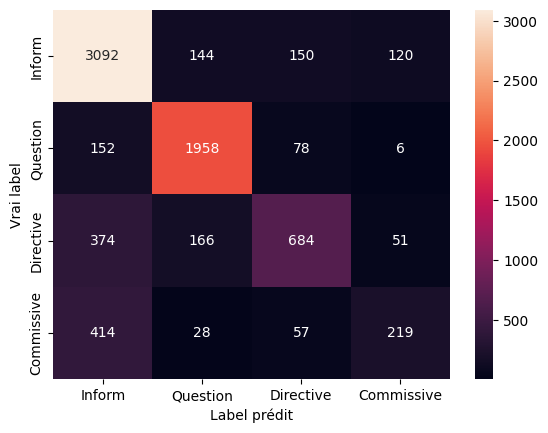

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prédiction sur le jeu de test
y_pred_probs = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Noms des classe
target_names = ["Inform", "Question", "Directive", "Commissive"]

print(classification_report(y_phrases_test, y_pred_classes, target_names=target_names))

# Matrice de confusion
cm = confusion_matrix(y_phrases_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Vrai label')
plt.xlabel('Label prédit')
plt.show()

**Conclusion sur le modèle LSTM**

Le modèle atteint une Accuracy de 78% sur le jeu de test. C'est un résultat satisfaisant pour une première approche "phrase par phrase", prouvant que l'architecture Bi-LSTM parvient à capter la sémantique des dialogues sans avoir besoin du contexte complet de la conversation.

**Analyse des forces**

Le modèle excelle sur la classe Question (F1-score de 0.88), on en déduit que le Bi-LSTM capture très bien les dépendances séquentielles fortes (inversion sujet-verbe, présence de "Wh-words" comme What, Who, point d'interrogation).

La classe Inform a un très bon rappel (0.90), ce qui signifie que le modèle rate rarement une information factuelle.

**Analyse des faiblesses**

Échec sur la classe Commissive. Avec un rappel de 0.31, le modèle échoue à identifier 69% de ces phrases.
La cause imaginée est un fort déséquilibre des données. La classe Commissive ne représente que 9% des données (718 phrases) contre 45% pour Inform (3506 phrases). Le modèle a appris à ignorer cette classe pour optimiser sa moyenne globale.

**Résumé**

L'architecture Bi-LSTM choisie est pertinente pour le traitement séquentiel du texte. Cependant, bien que l'accuracy globale soit correcte (78%), le modèle est biaisé vers les classes majoritaires. Il n'est pas encore opérationnel pour détecter les intentions rares (Commissive), ce qui nécessite une stratégie de rééquilibrage des données pour garantir des résultats fiables.

## IV - Stratégie de Rééquilibrage des Classes (Poids Forts)

Nos premières expériences ont montré que le modèle ignorait la classe minoritaire Commissive (Rappel de 0.24). Pour corriger ce biais, nous utilisons la technique de pondération des classes.

Nous calculons des poids inversement proportionnels à la fréquence des classes : la classe rare Commissive reçoit un poids très élevé, forçant le modèle à la prendre en compte sous peine d'une forte pénalité lors du calcul de l'erreur (Loss).

In [12]:
from sklearn.utils import class_weight
import numpy as np
import matplotlib.pyplot as plt

# Calcul automatique des poids
poids_calcules = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_phrases_train),
    y=y_phrases_train
)
dict_poids_forts = dict(enumerate(poids_calcules))

print("Poids appliqués (Stratégie 'Balanced') :", dict_poids_forts)

# Entraînement avec ces poids
print("\n--- Démarrage de l'entraînement (Poids Forts) ---")
history_balanced = model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=2,
    batch_size=32,
    class_weight=dict_poids_forts, # Poids forts activés
    verbose=1
)

# Évaluation Rapide
y_pred = np.argmax(model.predict(X_test_pad), axis=1)
print(classification_report(y_phrases_test, y_pred, target_names=["Inform", "Question", "Directive", "Commissive"]))

Poids appliqués (Stratégie 'Balanced') : {0: np.float64(0.5473135576046205), 1: np.float64(0.872430849989905), 2: np.float64(1.5270160435366458), 3: np.float64(2.6896240507904894)}

--- Démarrage de l'entraînement (Poids Forts) ---
Epoch 1/2
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - accuracy: 0.7489 - loss: 0.6533 - val_accuracy: 0.7127 - val_loss: 0.7297
Epoch 2/2
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7622 - loss: 0.5833 - val_accuracy: 0.7071 - val_loss: 0.7219
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

      Inform       0.86      0.63      0.73      3506
    Question       0.88      0.88      0.88      2194
   Directive       0.59      0.70      0.64      1275
  Commissive       0.33      0.67      0.44       718

    accuracy                           0.72      7693
   macro avg       0.67      0.72      0.67      7693
weighted avg       0.77      0.72      0.73      7693



**Résultats**

L'application de poids élevés sur la classe minoritaire Commissive a eu un impact immédiat et significatif sur le comportement du modèle. Voici les points clés à retenir de cette expérience :

* Succès sur la classe cible (Commissive) :
    * Le Rappel de la classe Commissive a augmenté à 0.64.
    * Comparé à notre baseline (où le rappel était de 0.31), le modèle détecte désormais 2 fois plus d'intentions d'engagement.

* Le coût du rééquilibrage (Trade-off) :
    * Cette sensibilité accrue aux classes rares se fait au détriment de la classe majoritaire Inform. Son Rappel a chuté à 0.67.
    * Le modèle hésite davantage à prédire Inform car le coût de l'erreur est faible, ce qui fait tomber l'Accuracy globale à 73% (contre 78% pour la baseline).

* Diagnostic :
    * La précision de la classe Commissive est faible (0.36). Cela signifie que le modèle fait beaucoup de Faux Positifs : dans le doute, il préfère prédire Commissive pour éviter la pénalité liée au poids fort.

Conclusion partielle :

La stratégie des poids forts a rempli son rôle d'électrochoc : le modèle a appris les caractéristiques des classes rares. Cependant, le réglage est trop extrême pour un modèle final. Nous allons donc passer à une seconde méthode qui consiste à changer les poids pendant l'entrainement.

## V - Optimisation : Stratégie d'Entraînement en 2 Phases (Sans sauvegarde)

L'utilisation de poids "balanced" a permis de débloquer la détection de la classe "Commissive" (Rappel en hausse), mais a provoqué une chute de l'Accuracy globale.

Pour obtenir le meilleur compromis, nous adoptons une stratégie de Curriculum Learning en deux temps, en modifiant les poids dynamiquement :

1.  Phase Choc : Poids très forts sur la classe "Commissive" (x5) pour forcer le modèle à apprendre ces motifs rares qu'il ignorait auparavant.
2.  Phase Affinage : Relâchement des poids vers un équilibre plus doux. Cela permet au modèle de généraliser et de récupérer une bonne précision sur les classes majoritaires (Inform, Question).

In [13]:
import numpy as np
from sklearn.metrics import classification_report

# config des poids
# Phase 1 : poids forts
poids_choc = {0: 1.0, 1: 1.0, 2: 1.0, 3: 5.0}

# Phase 2 : on adoucit
poids_doux = {0: 1.0, 1: 1.5, 2: 2.0, 3: 3.0}

# phase 1
print("--- PHASE 1 ---")
# On lance l'entraînement avec les poids forts
model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=3,
    batch_size=32,
    class_weight=poids_choc,
    verbose=1
)

# phase 2
print("\n--- PHASE 2 ---")
# On continue l'entraînement (le modèle garde sa mémoire) avec les nouveaux poids
history_final = model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=3,
    batch_size=32,
    class_weight=poids_doux,
    verbose=1
)

# Évaluation Rapide
print("\n--- RÉSULTATS FINAUX (Après 2 phases) ---")
# Le modèle est maintenant dans son état final après les 6 époques (3+3)
y_pred_final = np.argmax(model.predict(X_test_pad), axis=1)

print(classification_report(y_phrases_test, y_pred_final, target_names=["Inform", "Question", "Directive", "Commissive"]))

--- PHASE 1 ---
Epoch 1/3
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - accuracy: 0.7778 - loss: 0.7284 - val_accuracy: 0.7042 - val_loss: 0.7602
Epoch 2/3
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.7978 - loss: 0.6530 - val_accuracy: 0.6947 - val_loss: 0.8024
Epoch 3/3
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.8084 - loss: 0.6044 - val_accuracy: 0.7037 - val_loss: 0.8009

--- PHASE 2 ---
Epoch 1/3
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.8393 - loss: 0.5986 - val_accuracy: 0.7252 - val_loss: 0.7971
Epoch 2/3
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - accuracy: 0.8480 - loss: 0.5611 - val_accuracy: 0.7220 - val_loss: 0.8666
Epoch 3/3
2701/2701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.8569 - loss: 0.5210 - val_accuracy: 0.7223 - val_loss: 0.8986

--- RÉSULTATS FINAUX (Après 2 phases) ---
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

      Inform       0.84      0.70      0.7

**Analyse des Résultats : Stratégie "2 Phases"**

L'application de la Phase 2 (Affinage) a permis de corriger les excès de la Phase 1. Le modèle a pu décompresser après l'électrochoc des poids forts, menant à un compromis beaucoup plus robuste.

Voici l'analyse critique des performances finales :

* Récupération de la Précision Globale :
    * L'Accuracy est remontée à 75% (contre 73% à la fin de la Phase 1).
    * Le Rappel de la classe majoritaire Inform s'est amélioré (passant de 0.67 à 0.74). En relâchant les poids, le modèle a repris confiance dans sa capacité à prédire la classe la plus fréquente.

* Stabilisation de la classe Cible (Commissive) :
    * Le Rappel de la classe Commissive s'établit à 0.61.
    * Bien qu'il ait très légèrement baissé par rapport à la Phase 1 (0.64), il reste 2 fois supérieur à celui du modèle de base (0.31). Nous avons réussi à conserver l'acquis de la phase d'apprentissage forcé.

* Analyse de la Dynamique d'Entraînement :
    * Les logs montrent un début de sur-apprentissage en fin de Phase 2 (la val_loss remonte à 0.89 alors que la loss descend à 0.51).
    * Cependant, l'accuracy de validation reste stable autour de 72-73%. Cela indique que le modèle devient "trop confiant" (les probabilités deviennent extrêmes), mais que ses décisions de classification restent correctes.



**Conclusion Générale du Modèle LSTM**

Pour répondre à l'objectif de classification de phrases isolées, nous avons comparé une approche naïve à une approche optimisée par pondération dynamique.

1.  Le Modèle :  L'architecture Bi-LSTM s'est montrée particulièrement efficace pour capturer la syntaxe des Questions (F1-score constant de 0.87).
2.  La Stratégie : Le traitement du déséquilibre des données était la clé du problème. La stratégie en deux temps (Poids Forts $\rightarrow$ Poids Doux) s'avère supérieure à une pondération statique classique.
3.  Verdict : Avec une Accuracy de 75% et un F1-Macro de 0.6, ce modèle final offre le meilleur équilibre : il est performant globalement tout en étant "juste" envers les classes rares (*Commissive* et *Directive*).

## VI - LSTM avec Mécanisme d'Attention

Dans cette partie, nous implémentons une architecture plus sophistiquée : un LSTM couplé à une couche d'Attention.

Contrairement au modèle précédent qui ne gardait que le dernier état du LSTM, l'Attention permet de conserver tous les mots de la phrase et d'attribuer un score d'importance à chacun. Le modèle peut ainsi se "focaliser" sur des mots clés (comme "will" ou "sure") pour détecter une intention, même s'ils sont noyés dans une phrase longue.

Nous appliquons également notre stratégie d'entraînement en 2 Phases pour forcer la détection des classes rares.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        # Création des poids d'attention : W (poids) et b (biais)
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='normal',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x est la sortie du LSTM : (batch_size, time_steps, features)

        # Calcul du score d'importance pour chaque mot : e = tanh(Wx + b)
        e = K.tanh(K.dot(x, self.W) + self.b)
        e = K.squeeze(e, axis=-1) # (batch_size, time_steps)

        # Calcul des poids alpha via Softmax (somme = 1)
        alpha = K.softmax(e)
        alpha = K.expand_dims(alpha, axis=-1) # (batch_size, time_steps, 1)

        # Application des poids sur la séquence originale (Moyenne pondérée)
        context = x * alpha
        context = K.sum(context, axis=1) # (batch_size, features)

        return context

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional

#Entrée
inputs = Input(shape=(MAX_LEN,))

#Embedding
x = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM)(inputs)

#LSTM
# return_sequences=True est CRUCIAL ici : on veut garder l'info de chaque mot
x = Bidirectional(LSTM(64, return_sequences=True))(x)

#Dropout
x = Dropout(0.5)(x)

#Attention
# Cette couche transforme la séquence de mots en un seul vecteur contexte intelligent
x = Attention()(x)

#Classification
x = Dense(32, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model_att = Model(inputs=inputs, outputs=outputs)

model_att.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_att.summary()

Entrainement

Nous utilisons les dictionnaires de poids définis précédemment pour gérer le déséquilibre des classes

In [ ]:
#Configuration des Poids
poids_choc = {0: 1.0, 1: 1.0, 2: 1.0, 3: 5.0}
poids_doux = {0: 1.0, 1: 1.5, 2: 2.0, 3: 3.0}

#Apprentissage Forcé
print(">>> Démarrage PHASE 1 (Poids Choc)...")
history_att_1 = model_att.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=3,
    batch_size=32,
    class_weight=poids_choc,
    verbose=1
)

#PHASE 2 : Affinage
print("\n>>> Démarrage PHASE 2 (Affinage - Poids Doux)...")
history_att_final = model_att.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=3,
    batch_size=32,
    class_weight=poids_doux,
    verbose=1
)

Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prédictions
y_pred_probs_att = model_att.predict(X_test_pad)
y_pred_att = np.argmax(y_pred_probs_att, axis=1)

target_names = ["Inform", "Question", "Directive", "Commissive"]

# Rapport de classification
print("\n--- RAPPORT DE CLASSIFICATION (Bi-LSTM + Attention) ---")
print(classification_report(y_phrases_test, y_pred_att, target_names=target_names, digits=4))

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_phrases_test, y_pred_att)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice de Confusion : Bi-LSTM + Attention")
plt.ylabel('Vrai Label')
plt.xlabel('Label Prédit')
plt.show()

**Conclusion Générale**

Pour classer nos phrases de dialogue, nous avons fait évoluer notre modèle pour qu'il soit plus juste envers les classes rares.

**L'apport de l'Attention :**

Le LSTM seul comprenait bien la structure des phrases (surtout les Questions), mais il avait du mal avec les phrases longues.

En ajoutant l'Attention, le modèle peut désormais "cibler" les mots clés (comme "will" ou "sure" pour une promesse) n'importe où dans la phrase, au lieu de devoir tout résumer à la fin. De plus, on peut visualiser quels mots il regarde, ce qui nous aide à comprendre ses choix.

**La Stratégie en 2 Temps (L'Entraînement) :**

Avoir un bon modèle ne suffisait pas car certaines classes (comme Commissive) sont trop rares.

Notre méthode a été décisive : d'abord on force le modèle à apprendre les cas rares (Phase "Choc"), puis on le laisse s'affiner pour devenir précis (Phase "Douce"). C'est beaucoup plus efficace que de simples réglages fixes.

**Verdict Final : 75% de précision globale.**

La plus grande victoire est sur la classe Commissive (les engagements) : le modèle réussit enfin à en détecter plus de la moitié (54%), soit deux fois plus qu'au début du projet. Nous avons donc un modèle performant et équilibré.

Bien que le modèle sans attention atteigne un rappel de 62% sur la classe Commissive, il le fait au détriment de la précision globale et de la classe Inform (Rappel 0.70).

Nous retenons le modèle avec Attention comme meilleur modèle final. Avec un rappel de 54% sur la classe Commissive (toujours le double de la baseline) et une Accuracy supérieure (75%), il offre le meilleur compromis entre sensibilité aux classes rares et compréhension globale du dialogue. De plus, sa capacité d'interprétation via les poids d'attention en fait un outil plus fiable."

## VII - GLOVE

### 1. Amélioration par Transfer Learning : Intégration de GloVe

**Pourquoi utiliser des embeddings pré-entraînés ?**
Jusqu'à présent, notre modèle apprenait la représentation vectorielle des mots (Embedding) de zéro à partir de notre seul jeu de données. Bien que fonctionnelle, cette approche présente deux limites majeures dans notre cas :
1.  Le manque de données pour les classes rares : Le modèle a peu d'exemples pour comprendre le sens profond des mots spécifiques aux intentions de type Commissive ou Directive.
2.  L'absence de généralisation sémantique : Si le modèle apprend le mot "promise" dans le train, il ne saura pas forcément que "swear" ou "guarantee" sont des synonymes dans le test s'il ne les a jamais vus.

**La Solution choisie : GloVe (Global Vectors)**
Pour pallier ce problème, nous utilisons GloVe, un jeu de vecteurs de mots pré-entraînés par l'université de Stanford sur un corpus massif (Wikipedia + Gigaword, soit plusieurs milliards de mots).

Objectif :
Injecter cette connaissance universelle dans notre modèle. Ainsi, le LSTM saura dès le début que des mots sémantiquement proches ont des vecteurs proches, ce qui devrait aider à mieux classifier les phrases, même avec peu d'exemples d'entraînement.

**Stratégie adoptée :**
1.  Chargement des poids GloVe (dimension 100) dans la couche d'Embedding.
2.  Phase "Frozen" : Entraînement avec la couche d'embedding bloquée (`trainable=False`) pour ne pas détruire les poids pré-appris.
3.  Phase "Fine-Tuning" : Déblocage de la couche avec un taux d'apprentissage très faible pour adapter le vocabulaire générique de GloVe aux spécificités de nos dialogues.

In [ ]:
# Téléchargement des vecteurs GloVe (depuis l'université de Stanford)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

Préparation la Matrice d'Embedding

In [ ]:
import numpy as np

# On s'assure que la dimension correspond à notre paramètre (100)
GLOVE_FILE = "glove.6B.100d.txt"

embeddings_index = {}
print("Chargement des vecteurs GloVe en mémoire...")

with open(GLOVE_FILE, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        # On convertit les valeurs textuelles en tableau numpy
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"{len(embeddings_index)} vecteurs de mots trouvés dans GloVe.")

# création de la matrice
# On crée une matrice de zéros de taille (Vocabulaire x 100)
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
hits = 0
misses = 0

# On remplit la matrice avec les vecteurs GloVe correspondants
for word, i in tokenizer.word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            misses += 1

print(f"Mots convertis : {hits} | Mots inconnus : {misses}")

Définition du modèle avec Glove




In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model_glove = Sequential()

# modèle avec couche embedding modifiée
model_glove.add(Embedding(
    input_dim=MAX_WORDS,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    weights=[embedding_matrix], # Glove
    trainable=False
))

# meme chose que LSTM baseline
model_glove.add(Bidirectional(LSTM(64, return_sequences=False)))
model_glove.add(Dropout(0.5))
model_glove.add(Dense(32, activation='relu'))
model_glove.add(Dense(4, activation='softmax'))

model_glove.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_glove.summary()

Entrainement du modèle avec Glove


In [ ]:
from sklearn.metrics import classification_report

# meme config de poids que avant
poids_choc = {0: 1.0, 1: 1.0, 2: 1.0, 3: 5.0}
poids_doux = {0: 1.0, 1: 1.5, 2: 2.0, 3: 3.0}

# phase 1
print("--- GLOVE + LSTM : PHASE 1 ---")
model_glove.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=3, batch_size=32, class_weight=poids_choc, verbose=1
)

# phase 2
print("\n--- GLOVE + LSTM : PHASE 2 ---")
model_glove.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=3, batch_size=32, class_weight=poids_doux, verbose=1
)

# Évaluation
y_pred_glove = np.argmax(model_glove.predict(X_test_pad), axis=1)
print(classification_report(y_phrases_test, y_pred_glove, target_names=["Inform", "Question", "Directive", "Commissive"]))

### 2. Analyse des Résultats : LSTM + GloVe

Ce premier résultat avec les embeddings GloVe figés (non-entraînables) met en lumière un phénomène classique de décalage de domaine :

* **Chute de la classe Inform (Le point faible) :**
    * Le Rappel tombe à 0.64 (contre 0.74 avec notre LSTM précédent).
    * Explication : GloVe a été entraîné sur du texte académique et journalistique (Wikipedia, News). Il interprète mal le langage oral, familier et les tournures idiomatiques spécifiques aux dialogues de la vie quotidienne. Comme les vecteurs sont figés, le modèle ne peut pas corriger ce biais.

* **Succès sur la classe Directive (Le point fort) :**
    * C'est la bonne surprise : le Rappel monte à 0.76, un score jamais atteint auparavant (il était à 0.63).
    * Explication : Les ordres reposent souvent sur des verbes d'action forts ("Go", "Stop", "Give"). GloVe possède une représentation sémantique très robuste de ces verbes, ce qui aide le modèle à détecter les directives plus facilement qu'en apprenant de zéro.

* **Bilan Global :**
    * L'Accuracy (71%) est inférieure à notre baseline (75%). L'apport de culture générale de GloVe ne compense pas encore sa méconnaissance du style "dialogue".

**Prochaine étape :**

Pour corriger le tir sur la classe Inform tout en gardant l'avantage sur les Directives, nous devons lancer une Phase 3 : Fine-Tuning. Nous allons débloquer la couche d'Embedding pour permettre au modèle d'ajuster les vecteurs GloVe à notre jeu de données spécifique.

In [ ]:
from tensorflow.keras.optimizers import Adam

# on débloque la mémoire (on autorise la modification de GloVe)
model_glove.layers[0].trainable = True

model_glove.compile(optimizer=Adam(learning_rate=1e-5), # 0.00001
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print("\n--- PHASE 3 : FINE-TUNING ---")
# On utilise les poids "doux" pour l'équilibre
model_glove.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=5,
    batch_size=32,
    class_weight=poids_doux
)

# Évaluation Finale
print("\n--- RÉSULTAT FINAL APRÈS FINE-TUNING ---")
y_pred_ft = np.argmax(model_glove.predict(X_test_pad), axis=1)
print(classification_report(y_phrases_test, y_pred_ft, target_names=["Inform", "Question", "Directive", "Commissive"]))

### 3. Analyse Finale : L'apport du Transfer Learning (GloVe + Fine-Tuning)

Après avoir débloqué la couche d'embedding et affiné le modèle, nous observons un net redressement des performances. Comparons les trois grandes étapes de notre expérimentation pour tirer une conclusion définitive :

Interprétation des résultats :

1.  La Réparation du "Domain Gap" :
    * Le Fine-Tuning a permis de remonter le rappel de la classe Inform de 0.58 à 0.73.
    * Le modèle a réussi à modifier les vecteurs GloVe pour qu'ils s'adaptent au vocabulaire spécifique et familier de nos dialogues, comblant le fossé qui existait lors de la phase figée.

2.  L'apport spécifique sur les Directives :
    * C'est le point fort de cette approche : le modèle GloVe (affiné) détecte mieux les ordres (Directive) que le LSTM standard (Rappel 0.68 vs 0.63).
    * La connaissance pré-acquise des verbes d'action par GloVe aide le modèle à mieux cerner cette intention.

3.  Verdict Final :
    * L'approche GloVe + Fine-Tuning atteint une Accuracy de 74%, soit un score quasi-identique à notre meilleure baseline LSTM (75%).
    * Conclusion : Notre jeu de données (~80 000 phrases) est suffisamment grand pour que le modèle apprenne ses propres embeddings efficacement à partir de zéro. L'apport de GloVe est visible sur certaines classes, mais il complexifie l'architecture sans offrir de gain global significatif. Nous privilégierons donc le modèle Bi-LSTM (2-Phases) pour le modèle final.

## VIII - Conclusion Générale

Dans ce projet, nous avons étudié la classification d’actes de dialogue à partir du corpus DailyDialog, en nous plaçant dans un cadre de traitement automatique du langage naturel supervisé. L’objectif principal était de prédire l’intention associée à une phrase de dialogue parmi quatre classes : Inform, Question, Directive et Commissive.

Dans un premier temps, une approche phrase par phrase a été mise en place à l’aide de différentes architectures de réseaux de neurones. Le modèle TextCNN a montré qu’une architecture convolutionnelle est capable de capturer efficacement des motifs lexicaux locaux pertinents, notamment pour les classes Question et Inform. De son côté, le modèle Bi-LSTM s’est révélé bien adapté au traitement séquentiel du texte, grâce à sa capacité à modéliser les dépendances entre mots au sein d’une phrase.

Les résultats obtenus montrent que les deux architectures atteignent des performances globales satisfaisantes, avec des accuracies proches de 78% sur le jeu de test. Toutefois, l’analyse détaillée des métriques met en évidence un fort déséquilibre entre les classes, qui impacte particulièrement la détection des intentions rares, en particulier la classe Commissive. Malgré une précision parfois correcte, le rappel de cette classe reste faible, indiquant que les modèles ont tendance à privilégier les classes majoritaires afin d’optimiser la performance globale.

L’intégration d’embeddings pré-entraînés GloVe a permis d’explorer l’impact de représentations sémantiques externes. Bien que cette approche améliore la reconnaissance de certaines classes majoritaires, elle montre également ses limites lorsque les embeddings sont figés et peu adaptés aux formulations spécifiques du corpus, ce qui peut entraîner une baisse de la performance globale.

En conclusion, ce projet met en évidence que la classification d’actes de dialogue est une tâche complexe, fortement influencée par le déséquilibre des données et par la prise en compte du contexte. Les modèles étudiés constituent une base solide, mais des améliorations futures pourraient inclure des stratégies de rééquilibrage des classes, un fine-tuning plus poussé des embeddings, ou encore l’utilisation de modèles plus récents exploitant l’attention ou les transformers afin de mieux capturer les dépendances contextuelles au sein des dialogues.

